In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "README.md").is_file() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").is_file():
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")


# EXP02 — iTransformer + Physics Feature Ablation + Optuna

이 노트북은 `train_final_physics_v2.csv`를 입력으로 사용합니다.

실험 순서:

1. 데이터 로드 / sanity check
2. feature group 정의
3. feature set별 usable-window 확인
4. iTransformer 고정 파라미터 ablation
5. competition-like validation score 확인
6. best feature set 선택
7. Optuna hyperparameter search
8. best model 재학습
9. lead-time별 RMSE / overall RMSE 저장
10. 모델, scaler, 실험 결과 저장

### 중요 원칙
- `INPUT_LEN = 289` (약 48시간)
- Forecast horizons = `+3/+6/+9/+12/+18/+24h`
- 미래 `hs` target은 `hs_original_observed == 1`인 값만 사용
- 복원된 `hs`는 historical input에는 사용 가능
- feature set마다 NaN 패턴이 다르므로 **각 feature set별 usable sample을 별도로 생성**
- validation은 chronological split
- `comp_rmse`는 origin `hs >= 1.5m` 기준으로 계산
- 최종 competition 제출용 검증에서는 78시간 separation 조건을 별도 적용할 수 있도록 함수 포함


In [1]:
# ============================================================
# 0. COLAB SETUP
# ============================================================

!pip -q install optuna

from pathlib import Path
import gc
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.7 MB/s eta 0:00:00
DEVICE: cuda
GPU: Tesla T4


In [3]:
# ============================================================
# 1. CONFIG
# ============================================================

DATA_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v2.csv")
TEST_CONTEXT_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_context.parquet")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")
SUBMISSION_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp02.csv")

EXP_DIR = PROJECT_ROOT / "artifacts" / "experiments" / "exp02"
EXP_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "time"
STATION_COL = "station"

STEP_MINUTES = 10
STEPS_PER_HOUR = 6

INPUT_LEN = 289
LEAD_HOURS = [3, 6, 9, 12, 18, 24]
LEAD_STEPS = [h * STEPS_PER_HOUR for h in LEAD_HOURS]
MAX_LEAD = max(LEAD_STEPS)
N_TARGETS = len(LEAD_STEPS)

TRAIN_RATIO = 0.80

# Ablation에서는 빠르게 확인
ABLATION_EPOCHS = 12
ABLATION_PATIENCE = 3

# Optuna
N_TRIALS = 30
OPTUNA_EPOCHS = 18
OPTUNA_PATIENCE = 4

# 최종 학습
FINAL_EPOCHS = 35
FINAL_PATIENCE = 6

NUM_WORKERS = 2 if torch.cuda.is_available() else 0

print("INPUT_LEN:", INPUT_LEN)
print("LEADS:", LEAD_HOURS)


INPUT_LEN: 289
LEADS: [3, 6, 9, 12, 18, 24]


In [4]:
# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df = (
    df
    .sort_values([STATION_COL, TIME_COL])
    .reset_index(drop=True)
)

print("shape:", df.shape)
print("stations:", df[STATION_COL].unique())
print("period:", df[TIME_COL].min(), "~", df[TIME_COL].max())

required = [
    "hs", "tp", "hmax",
    "hs_original_observed",
]

missing_required = [c for c in required if c not in df.columns]
assert not missing_required, f"Missing required columns: {missing_required}"

display(
    df.groupby(STATION_COL)
    .agg(
        rows=("hs", "size"),
        hs_missing=("hs", lambda s: s.isna().sum()),
        hs_original=("hs_original_observed", "sum"),
    )
)


shape: (183600, 66)
stations: ['G-ORS' 'I-ORS' 'S-ORS']
period: 2024-01-01 00:00:00+09:00 ~ 2025-06-30 23:50:00+09:00


,rows,hs_missing,hs_original
station,,,
G-ORS,78768,2110,38053
I-ORS,52416,8341,30899
S-ORS,52416,39,38978


In [5]:
# ============================================================
# 3. FEATURE POOL
# ============================================================

# 기존 EXP01에서 효과가 있었던 축 + V2 physics 후보를 그룹화
FEATURE_GROUPS = {

    "BASE_HS_TP": [
        "hs",
        "tp",
    ],

    "HMAX": [
        "hmax",
    ],

    "WIND_RAW": [
        "wspd",
        "gust",
    ],

    "ATMOS_RAW": [
        "airt",
        "relh",
        "caph",
    ],

    "WIND_VECTOR": [
        "u_wind",
        "v_wind",
    ],

    "WIND_FORCE": [
        "wspd2",
        "wspd3",
        "gust_minus_wspd",
    ],

    "WIND_HISTORY": [
        "wspd_mean_3h",
        "wspd_mean_6h",
        "wspd_mean_12h",
        "gust_max_3h",
        "gust_max_6h",
        "gust_max_12h",
        "wspd3_mean_6h",
    ],

    "PRESSURE_TENDENCY": [
        "caph_change_3h",
        "caph_change_6h",
        "caph_change_12h",
    ],

    "DIR_CYCLIC": [
        "wdir_sin",
        "wdir_cos",
        "wvdir_sin",
        "wvdir_cos",
    ],

    "WIND_WAVE_DIRECTION": [
        "wind_wave_diff",
        "wind_wave_alignment",
    ],

    "WAVE_PHYSICS": [
        "wave_steepness_proxy",
        "hs_tp_ratio",
        "wave_energy_proxy",
        "wave_power_proxy",
        "deepwater_wavelength",
        "phase_speed_proxy",
        "physical_steepness",
        "wave_age_proxy",
    ],
}

# 실제 csv에 있는 컬럼만 유지
for k, cols in list(FEATURE_GROUPS.items()):
    FEATURE_GROUPS[k] = [c for c in cols if c in df.columns]

print("=== FEATURE GROUPS ===")
for k, cols in FEATURE_GROUPS.items():
    print(k, "->", len(cols), cols)


=== FEATURE GROUPS ===
BASE_HS_TP -> 2 ['hs', 'tp']
HMAX -> 1 ['hmax']
WIND_RAW -> 2 ['wspd', 'gust']
ATMOS_RAW -> 3 ['airt', 'relh', 'caph']
WIND_VECTOR -> 2 ['u_wind', 'v_wind']
WIND_FORCE -> 3 ['wspd2', 'wspd3', 'gust_minus_wspd']
WIND_HISTORY -> 7 ['wspd_mean_3h', 'wspd_mean_6h', 'wspd_mean_12h', 'gust_max_3h', 'gust_max_6h', 'gust_max_12h', 'wspd3_mean_6h']
PRESSURE_TENDENCY -> 3 ['caph_change_3h', 'caph_change_6h', 'caph_change_12h']
DIR_CYCLIC -> 4 ['wdir_sin', 'wdir_cos', 'wvdir_sin', 'wvdir_cos']
WIND_WAVE_DIRECTION -> 2 ['wind_wave_diff', 'wind_wave_alignment']
WAVE_PHYSICS -> 8 ['wave_steepness_proxy', 'hs_tp_ratio', 'wave_energy_proxy', 'wave_power_proxy', 'deepwater_wavelength', 'phase_speed_proxy', 'physical_steepness', 'wave_age_proxy']


In [6]:
# ============================================================
# 4. CURATED ABLATION SETS
# ============================================================

def uniq(seq):
    return list(dict.fromkeys(seq))

BASE = FEATURE_GROUPS["BASE_HS_TP"]
HMAX = FEATURE_GROUPS["HMAX"]

FEATURE_SETS = {
    "BASE_HS_TP":
        uniq(BASE),

    "BASE_HMAX":
        uniq(BASE + HMAX),

    "BASE_HMAX_WIND":
        uniq(BASE + HMAX + FEATURE_GROUPS["WIND_RAW"]),

    "BASE_HMAX_WAVE_PHYSICS":
        uniq(BASE + HMAX + FEATURE_GROUPS["WAVE_PHYSICS"]),

    "BASE_HMAX_WIND_FORCE":
        uniq(BASE + HMAX + FEATURE_GROUPS["WIND_FORCE"]),

    "BASE_HMAX_WIND_HISTORY":
        uniq(BASE + HMAX + FEATURE_GROUPS["WIND_HISTORY"]),

    "BASE_HMAX_PRESSURE":
        uniq(BASE + HMAX + FEATURE_GROUPS["PRESSURE_TENDENCY"]),

    "BASE_HMAX_DIR":
        uniq(
            BASE + HMAX
            + FEATURE_GROUPS["DIR_CYCLIC"]
            + FEATURE_GROUPS["WIND_WAVE_DIRECTION"]
        ),

    "STORM_PHYSICS":
        uniq(
            BASE + HMAX
            + FEATURE_GROUPS["WIND_RAW"]
            + FEATURE_GROUPS["WIND_FORCE"]
            + FEATURE_GROUPS["WIND_HISTORY"]
            + FEATURE_GROUPS["PRESSURE_TENDENCY"]
        ),

    "WAVE_PHYSICS_ALL":
        uniq(
            BASE + HMAX
            + FEATURE_GROUPS["WAVE_PHYSICS"]
        ),

    "FULL_PHYSICS":
        uniq(
            BASE + HMAX
            + FEATURE_GROUPS["WIND_RAW"]
            + FEATURE_GROUPS["ATMOS_RAW"]
            + FEATURE_GROUPS["WIND_VECTOR"]
            + FEATURE_GROUPS["WIND_FORCE"]
            + FEATURE_GROUPS["WIND_HISTORY"]
            + FEATURE_GROUPS["PRESSURE_TENDENCY"]
            + FEATURE_GROUPS["DIR_CYCLIC"]
            + FEATURE_GROUPS["WIND_WAVE_DIRECTION"]
            + FEATURE_GROUPS["WAVE_PHYSICS"]
        ),
}

# 비어 있거나 존재하지 않는 컬럼 제거
for k, cols in list(FEATURE_SETS.items()):
    FEATURE_SETS[k] = [c for c in cols if c in df.columns]

display(
    pd.DataFrame([
        {
            "feature_set": k,
            "n_features": len(v),
            "features": ", ".join(v),
        }
        for k, v in FEATURE_SETS.items()
    ])
)


,feature_set,n_features,features
0,BASE_HS_TP,2,"hs, tp"
1,BASE_HMAX,3,"hs, tp, hmax"
2,BASE_HMAX_WIND,5,"hs, tp, hmax, wspd, gust"
3,BASE_HMAX_WAVE_PHYSICS,11,"hs, tp, hmax, wave_steepness_proxy, hs_tp_rati..."
4,BASE_HMAX_WIND_FORCE,6,"hs, tp, hmax, wspd2, wspd3, gust_minus_wspd"
5,BASE_HMAX_WIND_HISTORY,10,"hs, tp, hmax, wspd_mean_3h, wspd_mean_6h, wspd..."
6,BASE_HMAX_PRESSURE,6,"hs, tp, hmax, caph_change_3h, caph_change_6h, ..."
7,BASE_HMAX_DIR,9,"hs, tp, hmax, wdir_sin, wdir_cos, wvdir_sin, w..."
8,STORM_PHYSICS,18,"hs, tp, hmax, wspd, gust, wspd2, wspd3, gust_m..."
9,WAVE_PHYSICS_ALL,11,"hs, tp, hmax, wave_steepness_proxy, hs_tp_rati..."


In [7]:
# ============================================================
# 5. SAMPLE BUILDING
# ============================================================

STATION_TO_ID = {
    station: i
    for i, station in enumerate(sorted(df[STATION_COL].unique()))
}

def build_samples(frame, features, input_len=INPUT_LEN, lead_steps=LEAD_STEPS):
    X_list = []
    y_list = []
    origin_hs_list = []
    origin_time_list = []
    station_list = []
    end_idx_list = []

    max_lead = max(lead_steps)

    for station, g in frame.groupby(STATION_COL):
        g = g.sort_values(TIME_COL).reset_index(drop=True)

        Xv = g[features].to_numpy(dtype=np.float32)
        hsv = g["hs"].to_numpy(dtype=np.float32)
        obs = g["hs_original_observed"].to_numpy(dtype=np.int8)
        times = g[TIME_COL].to_numpy()

        # 연속 10분 grid 확인용
        dt = pd.Series(g[TIME_COL]).diff().dt.total_seconds().div(60).to_numpy()

        for end_idx in range(input_len - 1, len(g) - max_lead):
            start_idx = end_idx - input_len + 1

            # history가 실제 연속 10분 grid인지 확인
            local_dt = dt[start_idx + 1:end_idx + 1]
            if len(local_dt) and not np.all(local_dt == STEP_MINUTES):
                continue

            x = Xv[start_idx:end_idx + 1]
            if not np.isfinite(x).all():
                continue

            target_idx = np.asarray(
                [end_idx + s for s in lead_steps],
                dtype=int
            )

            y = hsv[target_idx]

            if not np.isfinite(y).all():
                continue

            # 미래 target은 원본 관측치만 허용
            if not np.all(obs[target_idx] == 1):
                continue

            origin_hs = hsv[end_idx]
            if not np.isfinite(origin_hs):
                continue

            X_list.append(x)
            y_list.append(y)
            origin_hs_list.append(origin_hs)
            origin_time_list.append(times[end_idx])
            station_list.append(STATION_TO_ID[station])
            end_idx_list.append(end_idx)

    if not X_list:
        return {
            "X": np.empty((0, input_len, len(features)), dtype=np.float32),
            "y": np.empty((0, len(lead_steps)), dtype=np.float32),
            "origin_hs": np.empty((0,), dtype=np.float32),
            "origin_time": np.empty((0,), dtype="datetime64[ns]"),
            "station_id": np.empty((0,), dtype=np.int64),
            "end_idx": np.empty((0,), dtype=np.int64),
        }

    return {
        "X": np.asarray(X_list, dtype=np.float32),
        "y": np.asarray(y_list, dtype=np.float32),
        "origin_hs": np.asarray(origin_hs_list, dtype=np.float32),
        "origin_time": np.asarray(origin_time_list),
        "station_id": np.asarray(station_list, dtype=np.int64),
        "end_idx": np.asarray(end_idx_list, dtype=np.int64),
    }


def chronological_split(samples, train_ratio=TRAIN_RATIO):
    times = pd.to_datetime(samples["origin_time"])
    cutoff = pd.Series(times).quantile(train_ratio)

    train_mask = times <= cutoff
    valid_mask = times > cutoff

    train = {k: v[train_mask] for k, v in samples.items()}
    valid = {k: v[valid_mask] for k, v in samples.items()}

    return train, valid, pd.Timestamp(cutoff)


def scale_samples(train, valid):
    n_features = train["X"].shape[-1]

    scaler = StandardScaler()
    scaler.fit(
        train["X"].reshape(-1, n_features)
    )

    train_scaled = dict(train)
    valid_scaled = dict(valid)

    train_scaled["X"] = scaler.transform(
        train["X"].reshape(-1, n_features)
    ).reshape(train["X"].shape).astype(np.float32)

    valid_scaled["X"] = scaler.transform(
        valid["X"].reshape(-1, n_features)
    ).reshape(valid["X"].shape).astype(np.float32)

    return train_scaled, valid_scaled, scaler


In [8]:
# ============================================================
# 6. USABLE WINDOW REPORT
# ============================================================

window_records = []

for feature_name, features in FEATURE_SETS.items():
    samples = build_samples(df, features)

    station_ids = samples["station_id"]

    record = {
        "feature_set": feature_name,
        "n_features": len(features),
        "usable_total": len(samples["y"]),
        "origin_hs_ge_1.5": int((samples["origin_hs"] >= 1.5).sum()),
    }

    for station, sid in STATION_TO_ID.items():
        record[f"{station}_n"] = int((station_ids == sid).sum())

    window_records.append(record)

window_report = pd.DataFrame(window_records)
display(window_report.sort_values("usable_total", ascending=False))

window_report.to_csv(
    EXP_DIR / "usable_windows.csv",
    index=False
)


,feature_set,n_features,usable_total,origin_hs_ge_1.5,G-ORS_n,I-ORS_n,S-ORS_n
0,BASE_HS_TP,2,59293,14748,34709,12442,12142
1,BASE_HMAX,3,59293,14748,34709,12442,12142
5,BASE_HMAX_WIND_HISTORY,10,57814,14342,33254,12430,12130
9,WAVE_PHYSICS_ALL,11,57742,14345,33159,12442,12141
3,BASE_HMAX_WAVE_PHYSICS,11,57742,14345,33159,12442,12141
6,BASE_HMAX_PRESSURE,6,57729,14271,33217,12406,12106
2,BASE_HMAX_WIND,5,57333,14345,33159,12288,11886
4,BASE_HMAX_WIND_FORCE,6,57333,14345,33159,12288,11886
8,STORM_PHYSICS,18,56826,14249,32723,12252,11851
7,BASE_HMAX_DIR,9,53516,13619,32843,10635,10038


In [9]:
# ============================================================
# 7. PYTORCH DATASET
# ============================================================

class WaveDataset(Dataset):
    def __init__(self, samples):
        self.X = torch.from_numpy(samples["X"]).float()
        self.y = torch.from_numpy(samples["y"]).float()
        self.origin_hs = torch.from_numpy(samples["origin_hs"]).float()
        self.station_id = torch.from_numpy(samples["station_id"]).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y[idx],
            self.origin_hs[idx],
            self.station_id[idx],
        )


def make_loader(samples, batch_size=128, shuffle=False):
    ds = WaveDataset(samples)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


In [10]:
# ============================================================
# 8. iTransformer
#
# 변수(token) 축으로 attention.
# 각 변수의 289-step history를 projection하여 token embedding 생성.
# ============================================================

class ITransformer(nn.Module):
    def __init__(
        self,
        seq_len,
        n_features,
        pred_len,
        d_model=64,
        n_heads=2,
        e_layers=3,
        dropout=0.25,
        d_ff=None,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.n_features = n_features
        self.pred_len = pred_len

        if d_ff is None:
            d_ff = d_model * 4

        # [B, L, N] -> [B, N, L] -> [B, N, D]
        self.value_embedding = nn.Linear(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=e_layers,
        )

        self.norm = nn.LayerNorm(d_model)

        # 변수 token들을 flatten 후 multi-horizon 예측
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len),
        )

    def forward(self, x):
        # x: [B, L, N]
        x = x.transpose(1, 2)      # [B, N, L]
        x = self.value_embedding(x)
        x = self.encoder(x)
        x = self.norm(x)
        out = self.head(x)
        return out


In [11]:
# ============================================================
# 9. METRICS
# ============================================================

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def lead_rmse(y_true, y_pred):
    return {
        f"rmse_{h}h": rmse(y_true[:, i], y_pred[:, i])
        for i, h in enumerate(LEAD_HOURS)
    }


def competition_like_rmse(y_true, y_pred, origin_hs):
    mask = origin_hs >= 1.5

    if mask.sum() == 0:
        return np.nan, 0

    return rmse(y_true[mask], y_pred[mask]), int(mask.sum())


def select_78h_separated_indices(times, station_ids, origin_hs, min_hours=78):
    # competition-style greedy selection:
    # origin hs >= 1.5 + 동일 station 내 최소 78h separation
    selected = []

    times = pd.to_datetime(times)

    for sid in np.unique(station_ids):
        idx = np.where(
            (station_ids == sid) &
            (origin_hs >= 1.5)
        )[0]

        idx = idx[np.argsort(times[idx])]

        last_time = None

        for i in idx:
            t = times[i]

            if last_time is None or (t - last_time) >= pd.Timedelta(hours=min_hours):
                selected.append(i)
                last_time = t

    return np.asarray(selected, dtype=int)


def exact_competition_rmse(y_true, y_pred, samples):
    idx = select_78h_separated_indices(
        samples["origin_time"],
        samples["station_id"],
        samples["origin_hs"],
        min_hours=78,
    )

    if len(idx) == 0:
        return np.nan, 0

    return rmse(y_true[idx], y_pred[idx]), len(idx)


In [12]:
# ============================================================
# 10. TRAIN / EVAL FUNCTIONS
# ============================================================

def evaluate_model(model, loader):
    model.eval()

    preds = []
    ys = []
    origins = []

    with torch.no_grad():
        for X, y, origin_hs, _ in loader:
            X = X.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            pred = model(X)

            preds.append(pred.cpu().numpy())
            ys.append(y.cpu().numpy())
            origins.append(origin_hs.numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)
    origin_hs = np.concatenate(origins)

    overall = rmse(y_true, y_pred)
    comp, comp_n = competition_like_rmse(
        y_true,
        y_pred,
        origin_hs,
    )

    result = {
        "overall_rmse": overall,
        "comp_rmse": comp,
        "comp_valid_n": comp_n,
        **lead_rmse(y_true, y_pred),
    }

    return result, y_true, y_pred


def train_one_model(
    train_samples,
    valid_samples,
    params,
    max_epochs,
    patience,
    verbose=True,
):
    seed_everything(SEED)

    batch_size = params.get("batch_size", 128)

    train_loader = make_loader(
        train_samples,
        batch_size=batch_size,
        shuffle=True,
    )

    valid_loader = make_loader(
        valid_samples,
        batch_size=batch_size,
        shuffle=False,
    )

    model = ITransformer(
        seq_len=INPUT_LEN,
        n_features=train_samples["X"].shape[-1],
        pred_len=N_TARGETS,
        d_model=params["d_model"],
        n_heads=params["n_heads"],
        e_layers=params["e_layers"],
        dropout=params["dropout"],
        d_ff=params.get("d_ff", params["d_model"] * 4),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    criterion = nn.MSELoss()

    best_state = None
    best_score = np.inf
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()

        train_losses = []

        for X, y, _, _ in train_loader:
            X = X.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred = model(X)
            loss = criterion(pred, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            train_losses.append(loss.item())

        metrics, _, _ = evaluate_model(model, valid_loader)

        score = metrics["comp_rmse"]
        if not np.isfinite(score):
            score = metrics["overall_rmse"]

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            **metrics,
        })

        if verbose:
            print(
                f"Epoch {epoch:02d} | "
                f"train={np.mean(train_losses):.5f} | "
                f"overall={metrics['overall_rmse']:.5f} | "
                f"comp={metrics['comp_rmse']:.5f}"
            )

        if score < best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_metrics, y_true, y_pred = evaluate_model(
        model,
        valid_loader
    )

    return model, final_metrics, pd.DataFrame(history), y_true, y_pred


In [13]:
# ============================================================
# 11. FEATURE ABLATION
# ============================================================

FIXED_PARAMS = {
    "d_model": 64,
    "n_heads": 2,
    "e_layers": 3,
    "dropout": 0.25,
    "lr": 1.8e-5,
    "weight_decay": 2.6e-5,
    "batch_size": 128,
}

ablation_records = []

for feature_name, features in FEATURE_SETS.items():
    print("\n" + "=" * 90)
    print("ABLATION:", feature_name)
    print("N FEATURES:", len(features))
    print(features)

    samples = build_samples(df, features)

    if len(samples["y"]) < 1000:
        print("SKIP: usable samples too small")
        continue

    train_s, valid_s, cutoff = chronological_split(samples)
    train_s, valid_s, scaler = scale_samples(train_s, valid_s)

    print("train:", len(train_s["y"]))
    print("valid:", len(valid_s["y"]))
    print("cutoff:", cutoff)

    model, metrics, history, y_true, y_pred = train_one_model(
        train_s,
        valid_s,
        params=FIXED_PARAMS,
        max_epochs=ABLATION_EPOCHS,
        patience=ABLATION_PATIENCE,
        verbose=False,
    )

    exact_comp, exact_n = exact_competition_rmse(
        y_true,
        y_pred,
        valid_s,
    )

    record = {
        "feature_set": feature_name,
        "n_features": len(features),
        "train_n": len(train_s["y"]),
        "valid_n": len(valid_s["y"]),
        "cutoff": cutoff,
        **metrics,
        "exact_78h_comp_rmse": exact_comp,
        "exact_78h_n": exact_n,
    }

    ablation_records.append(record)

    print(pd.Series(record))

    del model, samples, train_s, valid_s, scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ablation_df = pd.DataFrame(ablation_records)

display(
    ablation_df
    .sort_values(
        ["comp_rmse", "overall_rmse"],
        ascending=True
    )
)

ablation_df.to_csv(
    EXP_DIR / "feature_ablation.csv",
    index=False
)



ABLATION: BASE_HS_TP
N FEATURES: 2
['hs', 'tp']
train: 47435
valid: 11858
cutoff: 2025-05-03 07:20:00+09:00
feature_set                           BASE_HS_TP
n_features                                     2
train_n                                    47435
valid_n                                    11858
cutoff                 2025-05-03 07:20:00+09:00
overall_rmse                            0.524259
comp_rmse                               0.516993
comp_valid_n                                 788
rmse_3h                                 0.437168
rmse_6h                                 0.490098
rmse_9h                                 0.530256
rmse_12h                                0.529891
rmse_18h                                 0.57508
rmse_24h                                0.570177
exact_78h_comp_rmse                     0.610793
exact_78h_n                                   23
dtype: object

ABLATION: BASE_HMAX
N FEATURES: 3
['hs', 'tp', 'hmax']
train: 47435
valid: 11858
cutoff: 202

,feature_set,n_features,train_n,valid_n,cutoff,overall_rmse,comp_rmse,comp_valid_n,rmse_3h,rmse_6h,rmse_9h,rmse_12h,rmse_18h,rmse_24h,exact_78h_comp_rmse,exact_78h_n
2,BASE_HMAX_WIND,5,45866,11467,2025-05-03 21:52:00+09:00,0.462909,0.485342,773,0.391519,0.432462,0.406875,0.475551,0.494850,0.555718,0.578776,22
4,BASE_HMAX_WIND_FORCE,6,45866,11467,2025-05-03 21:52:00+09:00,0.361802,0.492028,773,0.246155,0.283598,0.318063,0.358939,0.426966,0.481751,0.568673,22
8,STORM_PHYSICS,18,45462,11364,2025-05-04 10:00:00+09:00,0.383857,0.500162,751,0.290841,0.319565,0.343009,0.376468,0.439742,0.494579,0.581408,21
1,BASE_HMAX,3,47435,11858,2025-05-03 07:20:00+09:00,0.496858,0.503133,788,0.431388,0.426187,0.477940,0.490252,0.530297,0.602901,0.585558,23
5,BASE_HMAX_WIND_HISTORY,10,46253,11561,2025-05-04 18:40:00+09:00,0.486846,0.515911,751,0.375094,0.407908,0.495715,0.501031,0.532013,0.578985,0.620997,21
0,BASE_HS_TP,2,47435,11858,2025-05-03 07:20:00+09:00,0.524259,0.516993,788,0.437168,0.490098,0.530256,0.529891,0.575080,0.570177,0.610793,23
3,BASE_HMAX_WAVE_PHYSICS,11,46194,11548,2025-05-04 20:20:00+09:00,0.382117,0.542479,751,0.255078,0.306732,0.345027,0.383375,0.457331,0.491692,0.556673,21
9,WAVE_PHYSICS_ALL,11,46194,11548,2025-05-04 20:20:00+09:00,0.382117,0.542479,751,0.255078,0.306732,0.345027,0.383375,0.457331,0.491692,0.556673,21
6,BASE_HMAX_PRESSURE,6,46183,11546,2025-05-04 20:48:00+09:00,0.369348,0.558924,751,0.261979,0.303268,0.329576,0.366449,0.432809,0.477151,0.539403,21
7,BASE_HMAX_DIR,9,42814,10702,2025-05-02 14:00:00+09:00,0.476680,0.568780,781,0.389358,0.413344,0.442767,0.488919,0.530710,0.569345,0.605832,23


In [14]:
# ============================================================
# 12. CHOOSE BEST FEATURE SET
#
# 너무 적은 validation subset에서 우연히 잘 나온 feature set 방지:
# 최대 comp_valid_n의 80% 이상인 후보 중 comp_rmse 최소 선택
# ============================================================

assert len(ablation_df) > 0

max_comp_n = ablation_df["comp_valid_n"].max()

eligible = ablation_df[
    ablation_df["comp_valid_n"]
    >=
    0.80 * max_comp_n
].copy()

eligible = eligible.sort_values(
    ["comp_rmse", "overall_rmse"]
)

BEST_FEATURE_NAME = eligible.iloc[0]["feature_set"]
BEST_FEATURES = FEATURE_SETS[BEST_FEATURE_NAME]

print("BEST FEATURE SET:", BEST_FEATURE_NAME)
print("N FEATURES:", len(BEST_FEATURES))
print(BEST_FEATURES)

display(eligible)


BEST FEATURE SET: BASE_HMAX_WIND
N FEATURES: 5
['hs', 'tp', 'hmax', 'wspd', 'gust']


,feature_set,n_features,train_n,valid_n,cutoff,overall_rmse,comp_rmse,comp_valid_n,rmse_3h,rmse_6h,rmse_9h,rmse_12h,rmse_18h,rmse_24h,exact_78h_comp_rmse,exact_78h_n
2,BASE_HMAX_WIND,5,45866,11467,2025-05-03 21:52:00+09:00,0.462909,0.485342,773,0.391519,0.432462,0.406875,0.475551,0.494850,0.555718,0.578776,22
4,BASE_HMAX_WIND_FORCE,6,45866,11467,2025-05-03 21:52:00+09:00,0.361802,0.492028,773,0.246155,0.283598,0.318063,0.358939,0.426966,0.481751,0.568673,22
8,STORM_PHYSICS,18,45462,11364,2025-05-04 10:00:00+09:00,0.383857,0.500162,751,0.290841,0.319565,0.343009,0.376468,0.439742,0.494579,0.581408,21
1,BASE_HMAX,3,47435,11858,2025-05-03 07:20:00+09:00,0.496858,0.503133,788,0.431388,0.426187,0.477940,0.490252,0.530297,0.602901,0.585558,23
5,BASE_HMAX_WIND_HISTORY,10,46253,11561,2025-05-04 18:40:00+09:00,0.486846,0.515911,751,0.375094,0.407908,0.495715,0.501031,0.532013,0.578985,0.620997,21
0,BASE_HS_TP,2,47435,11858,2025-05-03 07:20:00+09:00,0.524259,0.516993,788,0.437168,0.490098,0.530256,0.529891,0.575080,0.570177,0.610793,23
3,BASE_HMAX_WAVE_PHYSICS,11,46194,11548,2025-05-04 20:20:00+09:00,0.382117,0.542479,751,0.255078,0.306732,0.345027,0.383375,0.457331,0.491692,0.556673,21
9,WAVE_PHYSICS_ALL,11,46194,11548,2025-05-04 20:20:00+09:00,0.382117,0.542479,751,0.255078,0.306732,0.345027,0.383375,0.457331,0.491692,0.556673,21
6,BASE_HMAX_PRESSURE,6,46183,11546,2025-05-04 20:48:00+09:00,0.369348,0.558924,751,0.261979,0.303268,0.329576,0.366449,0.432809,0.477151,0.539403,21
7,BASE_HMAX_DIR,9,42814,10702,2025-05-02 14:00:00+09:00,0.476680,0.568780,781,0.389358,0.413344,0.442767,0.488919,0.530710,0.569345,0.605832,23


In [15]:
# ============================================================
# 13. PREPARE FIXED DATA FOR OPTUNA
# ============================================================

best_samples = build_samples(
    df,
    BEST_FEATURES
)

train_samples, valid_samples, split_cutoff = chronological_split(
    best_samples
)

train_samples, valid_samples, best_scaler = scale_samples(
    train_samples,
    valid_samples
)

print("split cutoff:", split_cutoff)
print("train:", len(train_samples["y"]))
print("valid:", len(valid_samples["y"]))
print("high-wave valid:", int((valid_samples["origin_hs"] >= 1.5).sum()))


split cutoff: 2025-05-03 21:52:00+09:00
train: 45866
valid: 11467
high-wave valid: 773


In [16]:
# ============================================================
# 14. OPTUNA
# ============================================================

def objective(trial):
    d_model = trial.suggest_categorical(
        "d_model",
        [64, 128, 256]
    )

    valid_heads = [
        h for h in [2, 4, 8]
        if d_model % h == 0
    ]

    params = {
        "d_model": d_model,
        "n_heads": trial.suggest_categorical(
            "n_heads",
            valid_heads
        ),
        "e_layers": trial.suggest_int(
            "e_layers",
            2,
            4
        ),
        "dropout": trial.suggest_float(
            "dropout",
            0.05,
            0.35
        ),
        "lr": trial.suggest_float(
            "lr",
            5e-6,
            1e-4,
            log=True
        ),
        "weight_decay": trial.suggest_float(
            "weight_decay",
            1e-6,
            1e-3,
            log=True
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size",
            [64, 128, 256]
        ),
    }

    try:
        model, metrics, history, _, _ = train_one_model(
            train_samples,
            valid_samples,
            params=params,
            max_epochs=OPTUNA_EPOCHS,
            patience=OPTUNA_PATIENCE,
            verbose=False,
        )

        trial.set_user_attr(
            "overall_rmse",
            metrics["overall_rmse"]
        )

        trial.set_user_attr(
            "comp_valid_n",
            metrics["comp_valid_n"]
        )

        score = metrics["comp_rmse"]

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return score

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            raise optuna.TrialPruned("CUDA OOM")
        raise


study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="exp02_itransformer",
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    gc_after_trial=True,
)

print("BEST VALUE:", study.best_value)
print("BEST PARAMS:")
print(study.best_params)


[I 2026-08-28 05:01:03,637] A new study created in memory with name: exp02_itransformer
[I 2026-08-28 05:02:00,919] Trial 0 finished with value: 0.5471802353858948 and parameters: {'d_model': 128, 'n_heads': 2, 'e_layers': 2, 'dropout': 0.3098528437324805, 'lr': 3.027182927734626e-05, 'weight_decay': 0.000133112160807369, 'batch_size': 128}. Best is trial 0 with value: 0.5471802353858948.
[I 2026-08-28 05:02:26,395] Trial 1 finished with value: 0.5007401704788208 and parameters: {'d_model': 64, 'n_heads': 4, 'e_layers': 2, 'dropout': 0.23355586841671383, 'lr': 7.593739613361236e-06, 'weight_decay': 7.523742884534855e-06, 'batch_size': 256}. Best is trial 1 with value: 0.5007401704788208.
[I 2026-08-28 05:02:41,618] Trial 2 finished with value: 0.5598194003105164 and parameters: {'d_model': 256, 'n_heads': 4, 'e_layers': 2, 'dropout': 0.33466566117599994, 'lr': 9.021655603568134e-05, 'weight_decay': 0.0002661901888489054, 'batch_size': 256}. Best is trial 1 with value: 0.500740170478820

BEST VALUE: 0.48044532537460327
BEST PARAMS:
{'d_model': 256, 'n_heads': 8, 'e_layers': 4, 'dropout': 0.22893029477096613, 'lr': 3.1746702358041495e-05, 'weight_decay': 2.1516955269069436e-05, 'batch_size': 64}


In [17]:
# ============================================================
# 15. OPTUNA RESULTS
# ============================================================

trials_df = study.trials_dataframe()
display(
    trials_df.sort_values("value").head(20)
)

trials_df.to_csv(
    EXP_DIR / "optuna_trials.csv",
    index=False
)

with open(
    EXP_DIR / "best_params.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        study.best_params,
        f,
        indent=2,
        ensure_ascii=False
    )


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_d_model,params_dropout,params_e_layers,params_lr,params_n_heads,params_weight_decay,user_attrs_comp_valid_n,user_attrs_overall_rmse,state
13,13,0.480445,2026-08-28 05:11:45.966210,2026-08-28 05:12:53.028379,0 days 00:01:07.062169,64,256,0.228930,4,0.000032,8,0.000022,773,0.352679,COMPLETE
23,23,0.482963,2026-08-28 05:21:51.153551,2026-08-28 05:22:57.092354,0 days 00:01:05.938803,64,256,0.240758,4,0.000033,8,0.000003,773,0.353979,COMPLETE
21,21,0.484464,2026-08-28 05:19:37.332377,2026-08-28 05:20:44.121467,0 days 00:01:06.789090,64,256,0.251129,4,0.000030,8,0.000005,773,0.354041,COMPLETE
20,20,0.484610,2026-08-28 05:18:31.212282,2026-08-28 05:19:37.119494,0 days 00:01:05.907212,64,256,0.250338,4,0.000030,8,0.000003,773,0.354122,COMPLETE
17,17,0.484886,2026-08-28 05:15:20.503188,2026-08-28 05:16:25.713807,0 days 00:01:05.210619,64,256,0.260508,4,0.000033,8,0.000004,773,0.354149,COMPLETE
26,26,0.485046,2026-08-28 05:25:01.321788,2026-08-28 05:26:07.380246,0 days 00:01:06.058458,64,256,0.236387,4,0.000037,8,0.000012,773,0.353739,COMPLETE
12,12,0.485736,2026-08-28 05:10:38.964391,2026-08-28 05:11:45.693069,0 days 00:01:06.728678,64,256,0.218651,4,0.000043,8,0.000015,773,0.355141,COMPLETE
11,11,0.486133,2026-08-28 05:09:31.264795,2026-08-28 05:10:38.749803,0 days 00:01:07.485008,64,256,0.208099,4,0.000042,8,0.000024,773,0.355885,COMPLETE
10,10,0.486260,2026-08-28 05:08:22.897068,2026-08-28 05:09:31.047432,0 days 00:01:08.150364,64,256,0.215903,4,0.000043,8,0.000017,773,0.355100,COMPLETE
16,16,0.487173,2026-08-28 05:14:56.968197,2026-08-28 05:15:20.303387,0 days 00:00:23.335190,256,256,0.178987,4,0.000063,8,0.000009,773,0.364908,COMPLETE


In [18]:
# ============================================================
# 16. FINAL TRAIN WITH BEST PARAMS
# ============================================================

BEST_PARAMS = dict(study.best_params)

final_model, final_metrics, final_history, y_true, y_pred = train_one_model(
    train_samples,
    valid_samples,
    params=BEST_PARAMS,
    max_epochs=FINAL_EPOCHS,
    patience=FINAL_PATIENCE,
    verbose=True,
)

exact_comp_rmse, exact_comp_n = exact_competition_rmse(
    y_true,
    y_pred,
    valid_samples,
)

final_metrics["exact_78h_comp_rmse"] = exact_comp_rmse
final_metrics["exact_78h_n"] = exact_comp_n

print("\n===== FINAL METRICS =====")
display(pd.Series(final_metrics).to_frame("value"))

final_history.to_csv(
    EXP_DIR / "final_history.csv",
    index=False
)

pd.DataFrame(
    [final_metrics]
).to_csv(
    EXP_DIR / "final_metrics.csv",
    index=False
)


Epoch 01 | train=0.35842 | overall=0.35268 | comp=0.48045
Epoch 02 | train=0.27607 | overall=0.39573 | comp=0.58054
Epoch 03 | train=0.25605 | overall=0.39653 | comp=0.56681
Epoch 04 | train=0.23959 | overall=0.39278 | comp=0.55985
Epoch 05 | train=0.22274 | overall=0.40360 | comp=0.57348
Epoch 06 | train=0.20656 | overall=0.42866 | comp=0.65177
Epoch 07 | train=0.19333 | overall=0.47212 | comp=0.65543

===== FINAL METRICS =====


,value
overall_rmse,0.352679
comp_rmse,0.480445
comp_valid_n,773.000000
rmse_3h,0.251883
rmse_6h,0.292062
rmse_9h,0.317519
rmse_12h,0.356284
rmse_18h,0.412224
rmse_24h,0.447063
exact_78h_comp_rmse,0.593357


,lead_hour,rmse
0,3,0.251883
1,6,0.292062
2,9,0.317519
3,12,0.356284
4,18,0.412224
5,24,0.447063


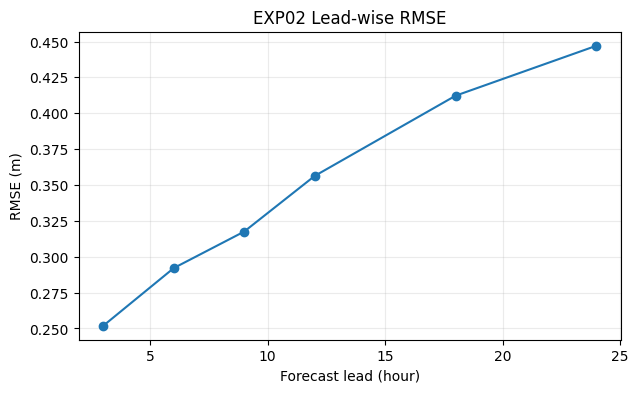

In [19]:
# ============================================================
# 17. LEAD-WISE RESULT
# ============================================================

lead_result = pd.DataFrame({
    "lead_hour": LEAD_HOURS,
    "rmse": [
        rmse(
            y_true[:, i],
            y_pred[:, i]
        )
        for i in range(N_TARGETS)
    ],
})

display(lead_result)

lead_result.to_csv(
    EXP_DIR / "lead_rmse.csv",
    index=False
)

plt.figure(figsize=(7, 4))
plt.plot(
    lead_result["lead_hour"],
    lead_result["rmse"],
    marker="o"
)
plt.xlabel("Forecast lead (hour)")
plt.ylabel("RMSE (m)")
plt.title("EXP02 Lead-wise RMSE")
plt.grid(True, alpha=0.25)
plt.show()


In [20]:
# ============================================================
# 18. HIGH-WAVE PERFORMANCE
# ============================================================

rows = []

for threshold in [1.0, 1.5, 2.0, 3.0]:
    mask = valid_samples["origin_hs"] >= threshold

    if mask.sum() == 0:
        continue

    rows.append({
        "origin_hs_threshold": threshold,
        "n": int(mask.sum()),
        "overall_rmse": rmse(
            y_true[mask],
            y_pred[mask]
        ),
        **{
            f"rmse_{h}h": rmse(
                y_true[mask, i],
                y_pred[mask, i]
            )
            for i, h in enumerate(LEAD_HOURS)
        }
    })

high_wave_df = pd.DataFrame(rows)
display(high_wave_df)

high_wave_df.to_csv(
    EXP_DIR / "high_wave_metrics.csv",
    index=False
)


,origin_hs_threshold,n,overall_rmse,rmse_3h,rmse_6h,rmse_9h,rmse_12h,rmse_18h,rmse_24h
0,1.0,2643,0.433855,0.334899,0.382966,0.402615,0.456456,0.487606,0.512199
1,1.5,773,0.480445,0.388398,0.438511,0.451217,0.505653,0.532962,0.546344
2,2.0,181,0.491433,0.436392,0.512201,0.506836,0.541419,0.521048,0.418019
3,3.0,3,0.559744,0.584445,0.229058,0.936404,0.703295,0.190969,0.279094


In [26]:
# ============================================================
# 19. SAVE MODEL + SCALER + METADATA
# ============================================================

import joblib

torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "features": BEST_FEATURES,
        "feature_set_name": BEST_FEATURE_NAME,
        "input_len": INPUT_LEN,
        "lead_hours": LEAD_HOURS,
        "params": BEST_PARAMS,
        "station_to_id": STATION_TO_ID,
        "metrics": final_metrics,
    },
    EXP_DIR / "best_model.pt",
)

joblib.dump(
    best_scaler,
    EXP_DIR / "scaler.pkl"
)

metadata = {
    "data_path": str(DATA_PATH),
    "feature_set_name": BEST_FEATURE_NAME,
    "features": BEST_FEATURES,
    "input_len": INPUT_LEN,
    "lead_hours": LEAD_HOURS,
    "split_cutoff": str(split_cutoff),
    "train_n": int(len(train_samples["y"])),
    "valid_n": int(len(valid_samples["y"])),
    "best_params": BEST_PARAMS,
    "metrics": {
        k: (
            float(v)
            if isinstance(v, (float, np.floating))
            else int(v)
            if isinstance(v, (int, np.integer))
            else v
        )
        for k, v in final_metrics.items()
    },
}

with open(
    EXP_DIR / "metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Saved EXP02 artifacts to:", EXP_DIR.resolve())


Saved EXP02 artifacts to: /content/experiments/exp02


## EXP02 결과 해석 기준

우선순위는 다음처럼 보면 됩니다.

1. **`comp_rmse`**  
   validation origin `hs >= 1.5m`인 전체 case 기준. feature ablation / Optuna의 주 objective.

2. **`exact_78h_comp_rmse`**  
   동일 station에서 forecast origin을 최소 78시간 간격으로 greedy selection한 competition-faithful 보조 점수.

3. **`overall_rmse`**  
   전체 validation sample 성능.

4. **lead-wise RMSE**  
   `+3/+6/+9/+12/+18/+24h` 중 어느 horizon이 악화되는지 확인.

### 주의
`FULL_PHYSICS`가 usable sample을 크게 잃으면 feature 자체가 나쁜 것이 아니라, atmospheric outage 때문에 sample selection이 달라진 효과일 수 있습니다.  
그래서 이 노트북은 feature set마다 sample을 별도로 생성하고, `comp_valid_n`이 최대값의 80% 이상인 후보들 중 best feature set을 선택합니다.


In [31]:
# ============================================================
# FINAL CELL
# TEST INFERENCE + COMPETITION SUBMISSION
#
# INPUT
#   train_final_v2.csv
#   test_context.parquet
#   test_index.csv
#
# OUTPUT
#   submission_exp02.csv
#
# Requires from previous EXP02 cells:
#   BEST_FEATURE_NAME
#   BEST_FEATURES
#   best_scaler
#   final_model
#   INPUT_LEN
#   LEAD_HOURS
#   DEVICE
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ============================================================
# PATHS
# ============================================================

TRAIN_BASE_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v2.csv")
TEST_CONTEXT_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_context.parquet")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")
SUBMISSION_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp02.csv")


# ============================================================
# CONSTANTS
# ============================================================

G = 9.80665
EPS = 1e-6


# ============================================================
# 1. LOAD TRAIN BASE
# ============================================================

train_base = pd.read_csv(
    TRAIN_BASE_PATH,
    parse_dates=["time"]
)


# ============================================================
# 2. TRAIN-BASED HMAX / HS RATIO
# ============================================================

ratio_df = train_base[
    train_base["hs"].notna()
    &
    train_base["hmax"].notna()
    &
    (train_base["hs"] > 0)
].copy()


ratio_df["hmax_hs_ratio"] = (
    ratio_df["hmax"]
    /
    ratio_df["hs"]
)


ratio_df = ratio_df[
    ratio_df["hmax_hs_ratio"]
    .between(1.0, 3.0)
]


HMAX_RATIO_BY_STATION = (
    ratio_df
    .groupby("station")["hmax_hs_ratio"]
    .median()
    .to_dict()
)


GLOBAL_HMAX_RATIO = float(
    ratio_df["hmax_hs_ratio"]
    .median()
)


print("===== HMAX/HS RATIO =====")
print(HMAX_RATIO_BY_STATION)
print("GLOBAL:", GLOBAL_HMAX_RATIO)


# ============================================================
# 3. TRAIN-BASED STATION FALLBACKS
#
# test case 전체가 특정 변수 NaN인 경우
# 같은 station의 train median 사용
# ============================================================

FALLBACK_COLS = [
    "tp",
    "wspd",
    "gust",
    "airt",
    "relh",
    "caph",
    "wdir",
    "wvdir",
]


STATION_MEDIANS = (
    train_base
    .groupby("station")[FALLBACK_COLS]
    .median()
)


GLOBAL_MEDIANS = (
    train_base[FALLBACK_COLS]
    .median()
)


print("\n===== STATION FALLBACK MEDIANS =====")
display(STATION_MEDIANS)


# ============================================================
# HELPERS
# ============================================================

def get_station_fallback(station, col):

    value = np.nan

    if (
        station in STATION_MEDIANS.index
        and col in STATION_MEDIANS.columns
    ):
        value = STATION_MEDIANS.loc[
            station,
            col
        ]

    if not np.isfinite(value):
        value = GLOBAL_MEDIANS[col]

    return float(value)


# ============================================================
# 4. TEST FEATURE ENGINEERING
# ============================================================

def add_test_features(context):

    required = {
        "case_id",
        "station",
        "step_minute",
        "hs",
        "tp",
        "hmax",
        "wvdir",
        "wspd",
        "gust",
        "wdir",
        "airt",
        "relh",
        "caph",
    }


    missing = sorted(
        required
        -
        set(context.columns)
    )


    if missing:
        raise ValueError(
            f"test_context missing columns: {missing}"
        )


    feature_frames = []


    # fallback 사용 통계
    fallback_log = []


    for case_id, group in context.groupby(
        "case_id",
        sort=False
    ):

        group = (
            group
            .sort_values("step_minute")
            .copy()
        )


        if len(group) != INPUT_LEN:
            raise ValueError(
                f"{case_id}: expected {INPUT_LEN} rows, "
                f"got {len(group)}"
            )


        station = group["station"].iloc[0]


        # ====================================================
        # 5. INVALID VALUES -> NaN
        # ====================================================

        for col in [
            "hs",
            "tp",
            "hmax",
        ]:

            group.loc[
                group[col] <= 0,
                col
            ] = np.nan


        group.loc[
            group["wspd"] < 0,
            "wspd"
        ] = np.nan


        group.loc[
            group["gust"] < 0,
            "gust"
        ] = np.nan


        group.loc[
            ~group["relh"].between(
                0,
                100
            ),
            "relh"
        ] = np.nan


        group.loc[
            ~group["caph"].between(
                950,
                1050
            ),
            "caph"
        ] = np.nan


        group["wdir"] = (
            group["wdir"] % 360
        )


        group["wvdir"] = (
            group["wvdir"] % 360
        )


        # ====================================================
        # 6. SHORT CONTINUOUS GAPS
        # ====================================================

        continuous_cols = [
            "hs",
            "tp",
            "wspd",
            "gust",
            "airt",
            "relh",
            "caph",
        ]


        group[continuous_cols] = (
            group[continuous_cols]
            .interpolate(
                method="linear",
                limit=2,
                limit_direction="both"
            )
        )


        # ====================================================
        # 7. HMAX
        # ====================================================

        group["hmax"] = (
            group["hmax"]
            .interpolate(
                method="linear",
                limit=2,
                limit_direction="both"
            )
        )


        ratio = HMAX_RATIO_BY_STATION.get(
            station,
            GLOBAL_HMAX_RATIO
        )


        hmax_missing = (
            group["hmax"].isna()
            &
            group["hs"].notna()
        )


        if hmax_missing.any():

            fallback_log.append({
                "case_id": case_id,
                "station": station,
                "column": "hmax",
                "n_filled": int(
                    hmax_missing.sum()
                ),
                "method": "hs_station_ratio",
            })


            group.loc[
                hmax_missing,
                "hmax"
            ] = (
                group.loc[
                    hmax_missing,
                    "hs"
                ]
                *
                ratio
            )


        # ====================================================
        # 8. DIRECTION
        # ====================================================

        for col in [
            "wdir",
            "wvdir",
        ]:

            group[col] = (
                group[col]
                .ffill()
                .bfill()
            )


            # case 전체 결측
            if group[col].isna().any():

                n_missing = int(
                    group[col]
                    .isna()
                    .sum()
                )


                fallback_value = (
                    get_station_fallback(
                        station,
                        col
                    )
                )


                group[col] = (
                    group[col]
                    .fillna(
                        fallback_value
                    )
                )


                fallback_log.append({
                    "case_id": case_id,
                    "station": station,
                    "column": col,
                    "n_filled": n_missing,
                    "method": "station_median",
                })


            group[col] = (
                group[col] % 360
            )


        # ====================================================
        # 9. CONTINUOUS FFILL/BFILL
        # ====================================================

        group[continuous_cols] = (
            group[continuous_cols]
            .ffill()
            .bfill()
        )


        # ====================================================
        # 10. TRAIN STATION MEDIAN FALLBACK
        #
        # ffill/bfill 후에도 남아 있으면
        # case 전체가 비어 있었다는 의미
        # ====================================================

        station_fallback_cols = [
            "tp",
            "wspd",
            "gust",
            "airt",
            "relh",
            "caph",
        ]


        for col in station_fallback_cols:

            if group[col].isna().any():

                n_missing = int(
                    group[col]
                    .isna()
                    .sum()
                )


                fallback_value = (
                    get_station_fallback(
                        station,
                        col
                    )
                )


                group[col] = (
                    group[col]
                    .fillna(
                        fallback_value
                    )
                )


                fallback_log.append({
                    "case_id": case_id,
                    "station": station,
                    "column": col,
                    "n_filled": n_missing,
                    "method": "station_median",
                })


        # ====================================================
        # 11. HS CHECK
        #
        # hs 전체 결측만큼은 station median으로 만들지 않음.
        # model의 핵심 입력이므로 별도 확인
        # ====================================================

        if group["hs"].isna().all():

            raise ValueError(
                f"{case_id}: hs is entirely missing"
            )


        # 일부 hs NaN이면 context 내부 nearest fallback
        if group["hs"].isna().any():

            n_missing = int(
                group["hs"]
                .isna()
                .sum()
            )


            group["hs"] = (
                group["hs"]
                .ffill()
                .bfill()
            )


            fallback_log.append({
                "case_id": case_id,
                "station": station,
                "column": "hs",
                "n_filled": n_missing,
                "method": "context_nearest",
            })


        # ====================================================
        # 12. HMAX SECOND FALLBACK
        #
        # hs가 뒤늦게 채워진 위치 반영
        # ====================================================

        hmax_missing = (
            group["hmax"].isna()
            &
            group["hs"].notna()
        )


        if hmax_missing.any():

            n_missing = int(
                hmax_missing.sum()
            )


            group.loc[
                hmax_missing,
                "hmax"
            ] = (
                group.loc[
                    hmax_missing,
                    "hs"
                ]
                *
                ratio
            )


            fallback_log.append({
                "case_id": case_id,
                "station": station,
                "column": "hmax",
                "n_filled": n_missing,
                "method": "hs_station_ratio_second",
            })


        # ====================================================
        # 13. BASE PHYSICAL SANITY
        # ====================================================

        group["hs"] = (
            group["hs"]
            .clip(lower=0.01)
        )


        group["tp"] = (
            group["tp"]
            .clip(lower=0.01)
        )


        group["wspd"] = (
            group["wspd"]
            .clip(lower=0.0)
        )


        group["gust"] = (
            group["gust"]
            .clip(lower=0.0)
        )


        group["hmax"] = np.maximum(
            group["hmax"],
            group["hs"]
        )


        # gust >= wspd
        group["gust"] = np.maximum(
            group["gust"],
            group["wspd"]
        )


        # ====================================================
        # 14. CYCLIC DIRECTION
        # ====================================================

        wdir_rad = np.deg2rad(
            group["wdir"]
        )


        wvdir_rad = np.deg2rad(
            group["wvdir"]
        )


        group["wdir_sin"] = (
            np.sin(wdir_rad)
        )


        group["wdir_cos"] = (
            np.cos(wdir_rad)
        )


        group["wvdir_sin"] = (
            np.sin(wvdir_rad)
        )


        group["wvdir_cos"] = (
            np.cos(wvdir_rad)
        )


        # ====================================================
        # 15. WIND VECTOR
        # ====================================================

        group["u_wind"] = (
            group["wspd"]
            *
            np.sin(wdir_rad)
        )


        group["v_wind"] = (
            group["wspd"]
            *
            np.cos(wdir_rad)
        )


        # ====================================================
        # 16. WIND FORCE
        # ====================================================

        group["wspd2"] = (
            group["wspd"] ** 2
        )


        group["wspd3"] = (
            group["wspd"] ** 3
        )


        group["gust_minus_wspd"] = (
            group["gust"]
            -
            group["wspd"]
        )


        # ====================================================
        # 17. WIND-WAVE RELATION
        # ====================================================

        direction_diff = (
            (
                group["wdir"]
                -
                group["wvdir"]
                +
                180
            )
            %
            360
            -
            180
        )


        group["wind_wave_diff"] = (
            np.abs(
                direction_diff
            )
        )


        group["wind_wave_alignment"] = (
            np.cos(
                np.deg2rad(
                    direction_diff
                )
            )
        )


        # ====================================================
        # 18. WIND HISTORY
        # ====================================================

        group["wspd_mean_3h"] = (
            group["wspd"]
            .rolling(
                18,
                min_periods=6
            )
            .mean()
        )


        group["wspd_mean_6h"] = (
            group["wspd"]
            .rolling(
                36,
                min_periods=12
            )
            .mean()
        )


        group["wspd_mean_12h"] = (
            group["wspd"]
            .rolling(
                72,
                min_periods=24
            )
            .mean()
        )


        group["gust_max_3h"] = (
            group["gust"]
            .rolling(
                18,
                min_periods=6
            )
            .max()
        )


        group["gust_max_6h"] = (
            group["gust"]
            .rolling(
                36,
                min_periods=12
            )
            .max()
        )


        group["gust_max_12h"] = (
            group["gust"]
            .rolling(
                72,
                min_periods=24
            )
            .max()
        )


        group["wspd3_mean_6h"] = (
            (group["wspd"] ** 3)
            .rolling(
                36,
                min_periods=12
            )
            .mean()
        )


        # ====================================================
        # 19. PRESSURE
        # ====================================================

        group["caph_change_3h"] = (
            group["caph"]
            -
            group["caph"].shift(18)
        )


        group["caph_change_6h"] = (
            group["caph"]
            -
            group["caph"].shift(36)
        )


        group["caph_change_12h"] = (
            group["caph"]
            -
            group["caph"].shift(72)
        )


        # ====================================================
        # 20. WAVE PHYSICS
        # ====================================================

        group["wave_energy_proxy"] = (
            group["hs"] ** 2
        )


        group["wave_power_proxy"] = (
            group["hs"] ** 2
            *
            group["tp"]
        )


        group["wave_steepness_proxy"] = (
            group["hs"]
            /
            (
                group["tp"] ** 2
                +
                EPS
            )
        )


        group["hs_tp_ratio"] = (
            group["hs"]
            /
            (
                group["tp"]
                +
                EPS
            )
        )


        # ====================================================
        # 21. DEEP-WATER PHYSICS
        # ====================================================

        group["deepwater_wavelength"] = (
            G
            *
            group["tp"] ** 2
            /
            (
                2 * np.pi
            )
        )


        group["phase_speed_proxy"] = (
            G
            *
            group["tp"]
            /
            (
                2 * np.pi
            )
        )


        group["physical_steepness"] = (
            group["hs"]
            /
            (
                group["deepwater_wavelength"]
                +
                EPS
            )
        )


        group["wave_age_proxy"] = (
            group["phase_speed_proxy"]
            /
            (
                group["wspd"]
                +
                1.0
            )
        )


        # ====================================================
        # 22. TIME FEATURES
        # ====================================================

        if "time" in group.columns:

            group["time"] = pd.to_datetime(
                group["time"]
            )


            hour = (
                group["time"].dt.hour
                +
                group["time"].dt.minute
                /
                60.0
            )


            month = (
                group["time"].dt.month
            )


            group["hour_sin"] = (
                np.sin(
                    2
                    *
                    np.pi
                    *
                    hour
                    /
                    24
                )
            )


            group["hour_cos"] = (
                np.cos(
                    2
                    *
                    np.pi
                    *
                    hour
                    /
                    24
                )
            )


            group["month_sin"] = (
                np.sin(
                    2
                    *
                    np.pi
                    *
                    (month - 1)
                    /
                    12
                )
            )


            group["month_cos"] = (
                np.cos(
                    2
                    *
                    np.pi
                    *
                    (month - 1)
                    /
                    12
                )
            )


        # ====================================================
        # 23. INF -> NAN
        # ====================================================

        numeric_cols = (
            group
            .select_dtypes(
                include=np.number
            )
            .columns
        )


        group[numeric_cols] = (
            group[numeric_cols]
            .replace(
                [
                    np.inf,
                    -np.inf,
                ],
                np.nan
            )
        )


        # ====================================================
        # 24. CHECK BEST FEATURES
        # ====================================================

        missing_best = [
            col
            for col in BEST_FEATURES
            if col not in group.columns
        ]


        if missing_best:
            raise ValueError(
                f"{case_id}: "
                f"missing BEST_FEATURES: "
                f"{missing_best}"
            )


        # ====================================================
        # 25. ROLLING / LAG INITIAL BOUNDARY
        # ====================================================

        group[BEST_FEATURES] = (
            group[BEST_FEATURES]
            .bfill()
            .ffill()
        )


        # ====================================================
        # 26. FINAL CHECK
        # ====================================================

        values = (
            group[BEST_FEATURES]
            .to_numpy(
                dtype=np.float32
            )
        )


        if not np.isfinite(values).all():

            bad_cols = [
                col
                for col in BEST_FEATURES
                if not np.isfinite(
                    group[col]
                    .to_numpy(dtype=float)
                ).all()
            ]


            print(
                "\nFAILED CASE:",
                case_id
            )

            print(
                "station:",
                station
            )

            print(
                "bad columns:",
                bad_cols
            )

            print(
                group[bad_cols]
                .isna()
                .sum()
            )


            raise ValueError(
                f"{case_id}: "
                f"non-finite features remain: "
                f"{bad_cols}"
            )


        feature_frames.append(
            group
        )


    # --------------------------------------------------------
    # fallback report
    # --------------------------------------------------------

    if fallback_log:

        fallback_df = pd.DataFrame(
            fallback_log
        )

        print("\n===== TEST FALLBACK SUMMARY =====")

        display(
            fallback_df
            .groupby(
                [
                    "column",
                    "method",
                ],
                as_index=False
            )
            .agg(
                cases=(
                    "case_id",
                    "nunique"
                ),
                values_filled=(
                    "n_filled",
                    "sum"
                ),
            )
            .sort_values(
                [
                    "column",
                    "method",
                ]
            )
        )

    else:

        print(
            "\nNo test fallback was required."
        )


    return pd.concat(
        feature_frames,
        ignore_index=True
    )


# ============================================================
# 27. LOAD TEST
# ============================================================

test_context = pd.read_parquet(
    TEST_CONTEXT_PATH
)


test_index = pd.read_csv(
    TEST_INDEX_PATH
)


print(
    "\ntest_context:",
    test_context.shape
)

print(
    "test_index:",
    test_index.shape
)


# ============================================================
# 28. ORIGINAL TEST FULL-MISSING CASE REPORT
# ============================================================

check_cols = [
    "hs",
    "tp",
    "hmax",
    "wvdir",
    "wspd",
    "gust",
    "wdir",
    "airt",
    "relh",
    "caph",
]


full_missing_by_case = (
    test_context
    .groupby("case_id")[check_cols]
    .apply(
        lambda x:
        x.isna().all()
    )
)


print(
    "\n===== ENTIRELY MISSING TEST CASE COUNTS ====="
)

display(
    full_missing_by_case
    .sum()
    .sort_values(
        ascending=False
    )
    .to_frame(
        "n_cases"
    )
)


# ============================================================
# 29. CREATE TEST FEATURES
# ============================================================

test_features = add_test_features(
    test_context
)


print(
    "\nBEST FEATURE SET:",
    BEST_FEATURE_NAME
)

print(
    "BEST FEATURES:",
    BEST_FEATURES
)


# ============================================================
# 30. BUILD INPUT WINDOWS
# ============================================================

case_order = (
    test_index["case_id"]
    .drop_duplicates()
    .tolist()
)


windows = []


for case_id in case_order:

    group = (
        test_features.loc[
            test_features["case_id"]
            ==
            case_id
        ]
        .sort_values(
            "step_minute"
        )
    )


    if len(group) != INPUT_LEN:
        raise ValueError(
            f"{case_id}: expected "
            f"{INPUT_LEN} rows, "
            f"got {len(group)}"
        )


    X = (
        group[BEST_FEATURES]
        .to_numpy(
            dtype=np.float32
        )
    )


    if not np.isfinite(X).all():

        raise ValueError(
            f"{case_id}: "
            "non-finite model input remains"
        )


    windows.append(X)


X_test_raw = np.stack(
    windows
)


print(
    "\nX_test_raw:",
    X_test_raw.shape
)


# ============================================================
# 31. SCALE
# ============================================================

n_features = len(
    BEST_FEATURES
)


X_test = (
    best_scaler
    .transform(
        X_test_raw.reshape(
            -1,
            n_features
        )
    )
    .reshape(
        X_test_raw.shape
    )
    .astype(
        np.float32
    )
)


if not np.isfinite(
    X_test
).all():

    raise ValueError(
        "Scaled test input contains "
        "NaN/Inf"
    )


print(
    "X_test scaled:",
    X_test.shape
)


# ============================================================
# 32. MODEL INFERENCE
# ============================================================

final_model.eval()


predictions = []


with torch.no_grad():

    for start in range(
        0,
        len(X_test),
        256
    ):

        batch = (
            torch
            .from_numpy(
                X_test[
                    start:
                    start + 256
                ]
            )
            .to(
                DEVICE
            )
        )


        pred = (
            final_model(
                batch
            )
            .detach()
            .cpu()
            .numpy()
        )


        predictions.append(
            pred
        )


predictions = np.concatenate(
    predictions,
    axis=0
)


print(
    "Prediction shape:",
    predictions.shape
)


expected_shape = (
    len(case_order),
    len(LEAD_HOURS),
)


if (
    predictions.shape
    !=
    expected_shape
):

    raise ValueError(
        f"Prediction shape mismatch: "
        f"{predictions.shape} "
        f"!= {expected_shape}"
    )


# ============================================================
# 33. CREATE LONG-FORM PREDICTIONS
# ============================================================

prediction_rows = []


for case_id, row in zip(
    case_order,
    predictions
):

    for lead_h, prediction in zip(
        LEAD_HOURS,
        row
    ):

        prediction_rows.append({
            "case_id": case_id,
            "lead_h": lead_h,
            "hs_pred": float(
                prediction
            ),
        })


prediction_df = pd.DataFrame(
    prediction_rows
)


# ============================================================
# 34. MATCH TEST INDEX
# ============================================================

submission = (
    test_index
    .merge(
        prediction_df,
        on=[
            "case_id",
            "lead_h",
        ],
        how="left",
        validate="one_to_one",
    )
)


submission = submission[
    [
        "case_id",
        "station",
        "lead_h",
        "hs_pred",
    ]
]


# ============================================================
# 35. PHYSICAL CLIP
# ============================================================

submission["hs_pred"] = (
    submission["hs_pred"]
    .clip(
        lower=0.0,
        upper=30.0
    )
)


# ============================================================
# 36. FINAL VALIDATION
# ============================================================

if len(
    submission
) != len(
    test_index
):

    raise ValueError(
        "Submission row count mismatch."
    )


if submission[
    "hs_pred"
].isna().any():

    raise ValueError(
        "Submission contains NaN."
    )


if not np.isfinite(
    submission[
        "hs_pred"
    ]
).all():

    raise ValueError(
        "Submission contains Inf."
    )


expected_columns = [
    "case_id",
    "station",
    "lead_h",
    "hs_pred",
]


if (
    submission
    .columns
    .tolist()
    !=
    expected_columns
):

    raise ValueError(
        "Invalid submission columns."
    )


# ============================================================
# 37. SAVE
# ============================================================

submission.to_csv(
    SUBMISSION_PATH,
    index=False,
    encoding="utf-8"
)


# ============================================================
# 38. RESULT
# ============================================================

print(
    "\n"
    +
    "=" * 80
)

print(
    "EXP02 SUBMISSION CREATED"
)

print(
    "=" * 80
)


print(
    "Saved:",
    SUBMISSION_PATH
)

print(
    "Rows:",
    len(submission)
)

print(
    "Cases:",
    submission[
        "case_id"
    ].nunique()
)

print(
    "Lead hours:",
    sorted(
        submission[
            "lead_h"
        ].unique()
    )
)


print(
    "\nPrediction statistics:"
)

display(
    submission[
        "hs_pred"
    ]
    .describe()
)


print(
    "\nSubmission preview:"
)

display(
    submission
    .head(12)
)

===== HMAX/HS RATIO =====
{'G-ORS': 1.6457142857142857, 'I-ORS': 1.6334405144694533, 'S-ORS': 1.6458333333333335}
GLOBAL: 1.643192488262911

===== STATION FALLBACK MEDIANS =====


,tp,wspd,gust,airt,relh,caph,wdir,wvdir
station,,,,,,,,
G-ORS,5.640,7.324,8.130,14.12,76.170,1013.1050,174.30,164.825
I-ORS,6.070,7.760,8.430,12.06,67.485,1012.9825,190.92,167.020
S-ORS,5.345,7.290,7.987,8.21,74.510,1012.2280,234.16,216.320



test_context: (57800, 13)
test_index: (1200, 3)

===== ENTIRELY MISSING TEST CASE COUNTS =====


,n_cases
hmax,20
wspd,1
relh,1
airt,1
gust,1
wdir,1
caph,1
hs,0
tp,0
wvdir,0



===== TEST FALLBACK SUMMARY =====


,column,method,cases,values_filled
0,airt,station_median,1,289
1,caph,station_median,1,289
2,gust,station_median,1,289
3,hmax,hs_station_ratio,25,5848
4,hmax,hs_station_ratio_second,30,1649
5,relh,station_median,1,289
6,wdir,station_median,1,289
7,wspd,station_median,1,289



BEST FEATURE SET: BASE_HMAX_WIND
BEST FEATURES: ['hs', 'tp', 'hmax', 'wspd', 'gust']

X_test_raw: (200, 289, 5)
X_test scaled: (200, 289, 5)
Prediction shape: (200, 6)

EXP02 SUBMISSION CREATED
Saved: submission_exp02.csv
Rows: 1200
Cases: 200
Lead hours: [np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(18), np.int64(24)]

Prediction statistics:


,hs_pred
count,1200.000000
mean,1.502749
std,0.514673
min,0.353206
25%,1.195689
50%,1.460331
75%,1.756261
max,4.041175



Submission preview:


,case_id,station,lead_h,hs_pred
0,C0001,S-ORS,3,1.241370
1,C0001,S-ORS,6,1.166819
2,C0001,S-ORS,9,1.419503
3,C0001,S-ORS,12,1.313258
4,C0001,S-ORS,18,1.479672
5,C0001,S-ORS,24,1.601277
6,C0002,I-ORS,3,1.241535
7,C0002,I-ORS,6,1.171945
8,C0002,I-ORS,9,1.214103
9,C0002,I-ORS,12,1.162082
